# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [266]:
STUDENT_NAME = "Lê Nguyễn Minh Khôi"  # TODO: Họ và tên
STUDENT_ID = "2550109"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Lê Nguyễn Minh Khôi (2550109)


In [267]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\LeNguyenMinhKhoi\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [268]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [269]:
# TODO N1
row_max = np.max(logits, axis=1, keepdims=True)

shifted_logits = logits - row_max

exp_logits = np.exp(shifted_logits)

class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

predicted_classes = np.argmax(class_probabilities, axis=1)

confidence_scores = np.max(class_probabilities, axis=1)

# print(row_max.shape)
# print(shifted_logits.shape)
# print(exp_logits.shape)
print(class_probabilities)
print(predicted_classes)
print(confidence_scores)

[[0.65900114 0.24243297 0.09856589]
 [0.24472847 0.66524096 0.09003057]
 [0.00657326 0.01786798 0.97555875]
 [0.33333333 0.33333333 0.33333333]]
[0 1 2 0]
[0.65900114 0.66524096 0.97555875 0.33333333]


In [270]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [271]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [272]:
# TODO N2
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [273]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [274]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [275]:
# TODO N3
correct_mask = predicted_classes == true_labels
high_confidence_mask = confidence_scores >= 0.7
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)

print(correct_mask)
print(high_confidence_mask)
print(review_mask)
print(review_indices)

[ True False  True False]
[False False  True False]
[ True  True False  True]
(array([0, 1, 3]),)


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [276]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [277]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

augmented_batch = np.flip(normalized_batch, axis=2).copy()

augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
2. Missing value là ô dữ liệu bị thiếu.
3. Mức đánh giá rủi ro bảo hiểm 

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [278]:
# TODO D1
raw_df = pd.read_csv("data/automobile_raw.csv")

raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == "?").sum().sum()

print(raw_shape)
print(raw_missing_marker_count)

(205, 26)
59


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [279]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [280]:
# TODO D2
df_clean = raw_df.replace("?", np.nan)

for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
    
missing_by_column = df_clean[df_clean.columns].isna().sum() 
missing_pct = df_clean.isna().mean() * 100
print(missing_by_column)
# print(missing_pct)

symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?

--> Vì làm vậy sẽ làm mất đi ý nghĩa của các cột dữ liệu. Ví dụ điền số num_doors cùng với số cho price thì sẽ khá là vô nghĩa

- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?

--> Nên fill, vì price chỉ thiếu có 4 ô và giá xe là một dữ liệu quan trọng để phân tích các mối tương quan với các dữ liệu khác
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

--> Tùy vào yêu cầu bài toán mà quyết định fill bằng median, mean hay xóa bỏ

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [281]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [282]:
# TODO D3

analysis_df = df_clean[AUTO_FEATURES].dropna()

X_auto = analysis_df.to_numpy(dtype=np.float64)

auto_feature_mean = X_auto.mean(axis=0)

auto_feature_std = X_auto.std(axis=0)

X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [283]:
# TODO D4
price_index = df_clean["price"]

price_z = (price_index - price_index.mean()) / price_index.std()

price_outlier_mask = price_z.abs() > 2

price_outliers = df_clean[price_outlier_mask]




## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [284]:
# TODO D5
engine_price_corr = df_clean[["engine_size", "price"]].corr(method="pearson")
print(engine_price_corr)

print()

price_by_body_style = df_clean.groupby("body_style")["price"].agg("mean").sort_index()
print(price_by_body_style)

             engine_size     price
engine_size     1.000000  0.872335
price           0.872335  1.000000

body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

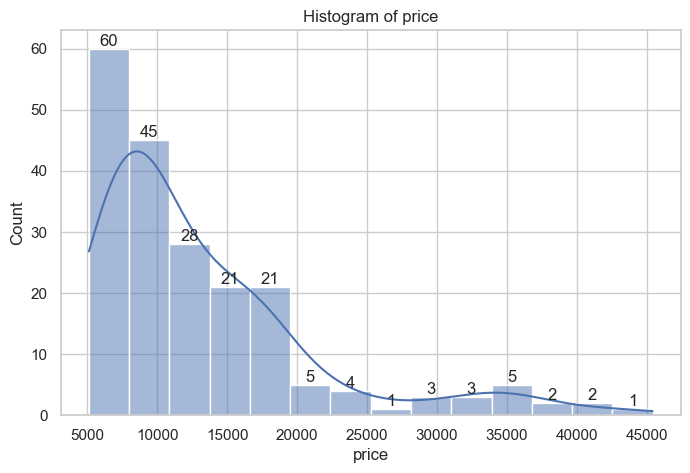

In [285]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(8,5))
ax = sns.histplot(data=df_clean, x="price", kde=True)
plt.title("Histogram of price")

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width()/2, height),
            ha="center",
            va="bottom"
        )

plt.show()

**Nhận xét:** 
- Phân phối này không tuân theo phân phối chuẩn
- Phân phối lệch phải, phần lớn giá trị nằm trong khoảng 5000-15000

## M2.2 Dataset có cân bằng theo body style không?

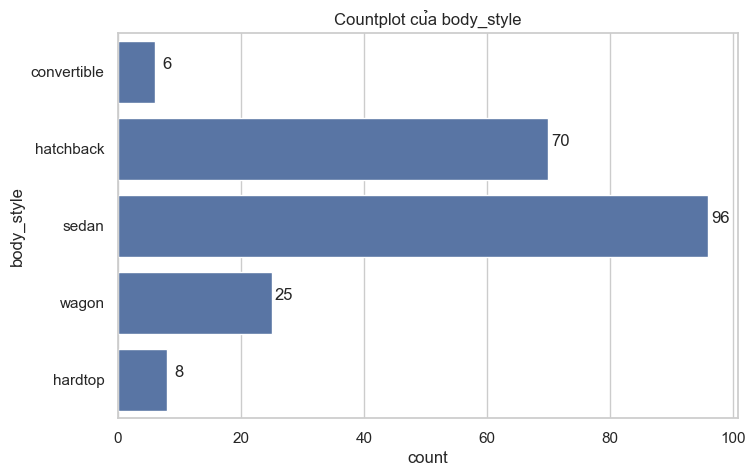

In [286]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(8,5))
ax = sns.countplot(df_clean["body_style"])

for p in ax.patches:
    width = p.get_width()

    ax.annotate(
        f"{int(width)}",
        (width + 2, p.get_y() + p.get_height()/2),
        ha="center",
        va="bottom"
    )
    
plt.title("Countplot của body_style")
plt.show()

**Nhận xét:** 

Dataset không cân bằng theo body_style. sedan là kiểu xe phổ biến nhất, trong khi convertible và hardtop có số lượng rất ít. Điều này cho thấy dữ liệu tập trung chủ yếu vào một số kiểu thân xe.

## M2.3 Price khác nhau theo body style ra sao?

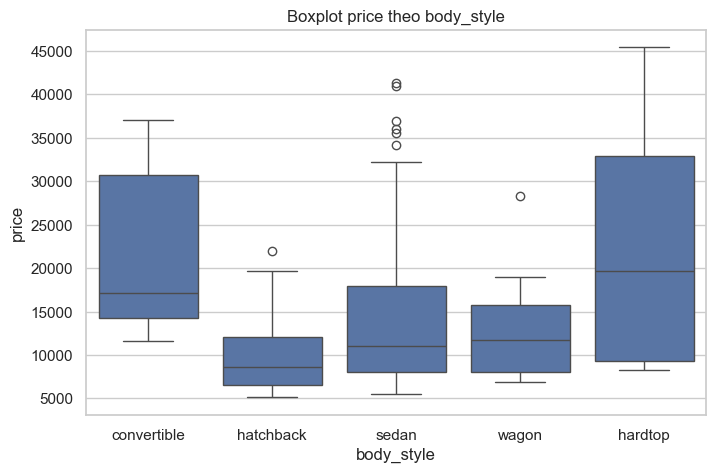

In [292]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x="body_style", y="price")
plt.title("Boxplot price theo body_style")
plt.show()


**Nhận xét:**

Boxplot price phân bố khá đều ở các mẫu wagon và hardtop

## M2.4 Engine size liên quan thế nào tới price?

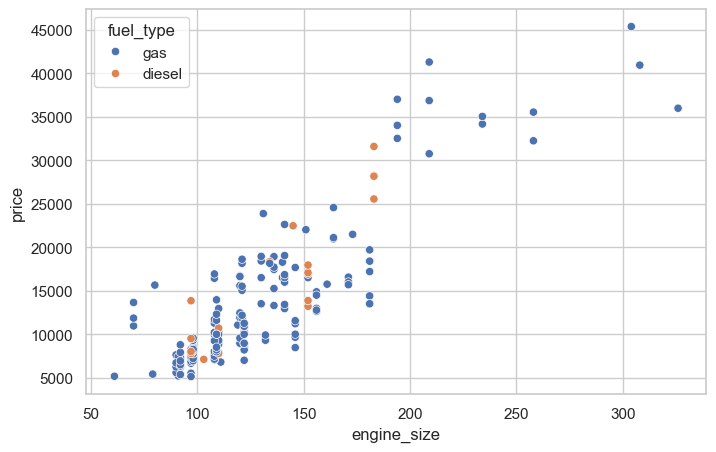

In [293]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_clean,
    x="engine_size",
    y="price",
    hue="fuel_type"
)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

## M2.5 Các feature numeric tương quan ra sao?

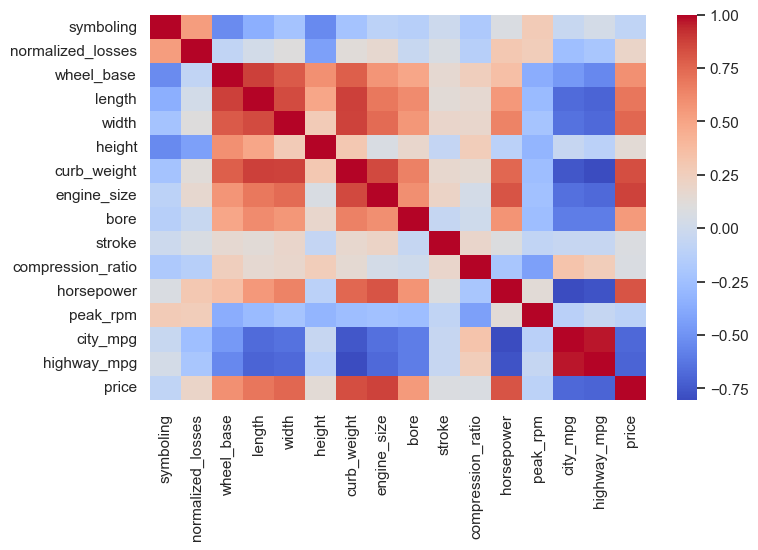

In [297]:
# TODO M2.5: correlation heatmap
numeric = df_clean.select_dtypes(include="number")
plt.figure(figsize=(8,5))
corr_matrix = numeric.corr()
sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

In [290]:
# TODO M2.6: biểu đồ tự chọn

**Nhận xét:** <!-- 1--2 câu -->

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->